# $\text{ARIMA}(p,d,q)$

ARIMA stands for Auto Regressive Integrated Moving Average. The intent of $\text{ARIMA}(p,d,q)$ is to construct a stationary, $\text{ARMA}(p,q)$ time series from a non-stationary time series by differencing $d$ times. Recall that an $\text{ARMA}(p,q)$ process is defined by,

$
\begin{align}
X_t = \varepsilon_t + \sum_{i=1}^p \varphi_i X_{t-i} + \sum_{i=1}^q \vartheta_i \varepsilon_{t-i}
\end{align}
\tag{1}
$

In terms of the lag operator $L X_t = X_{t-1}, L^2 X_t = X_{t-2}, L^3 X_t = X_{t-3}, \ldots$, The $\text{ARMA}(p,q)$ model can be written as,

$
\begin{align}
\left( 1 - \sum_{i=1}^p \varphi_i L^i \right) X_t = \left( 1  + \sum_{i=1}^q \vartheta_i L^i \right)\varepsilon_{t}
\end{align}
\tag{2}
$

The difference operator is given by $\Delta = (1 - L)$. If $X_t$ is stationary after $d$ differences it follows that $\left( 1 - L \right)^d X_t$ is stationary. This is the definition of integration order. Thus, $\text{ARIMA}(p,d,q)$ can be written as,

$
\begin{align}
\left( 1 - \sum_{i=1}^p \varphi_i L^i \right) \left( 1 - L \right)^d X_t = \left( 1  + \sum_{i=1}^q \vartheta_i L^i \right)\varepsilon_{t}
\end{align}
\tag{3}
$

The procedure followed to determine the order and coefficients of an $\text{ARIMA}(p,d,q)$ series is as follows.

1. Use ADF test to determine if series is stationary. To determine $d$ difference series until ADF test fails.
2. User PACF/ACF analysis to determine $p$ and $q$.
3. Perform regression on differenced series to determine coefficients.

## Includes

In [3]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import arima, stats, adf
from lib.plots import stack, comparison

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Helpers

In [4]:
nsample = 1000

def pacf_acf_plot(t, samples, nlags, σ, φ):
    title = f"AR(1) ACF-PACF σ={σ}, $\\varphi=${φ}"
    tacf, acf = stats.compute_acf(t, samples, nlags=nlags)
    tpacf, pacf = arima.compute_pacf(samples, nlags=nlags)
    comparison([acf, pacf], [tacf, tpacf], labels=["ACF", "PACF"], ylim=(-0.1, 1.0), title=title, figsize=(10, 6))

## $\text{ARIMA}(1,1,0)$ Example

In [5]:
nsample = 1000
σ = 1.0
nlags = 10

In [6]:
φ = [0.5]
d = 1
_, ar = arima.create_ar_source(φ=φ, npts=nsample)
t, arima_data = arima.create_arima_from_arma_source(arma=ar, d=d, npts=nsample)
tdiff_1, diff_1 = stats.compute_ndiff(t, arima_data, ndiff=1)

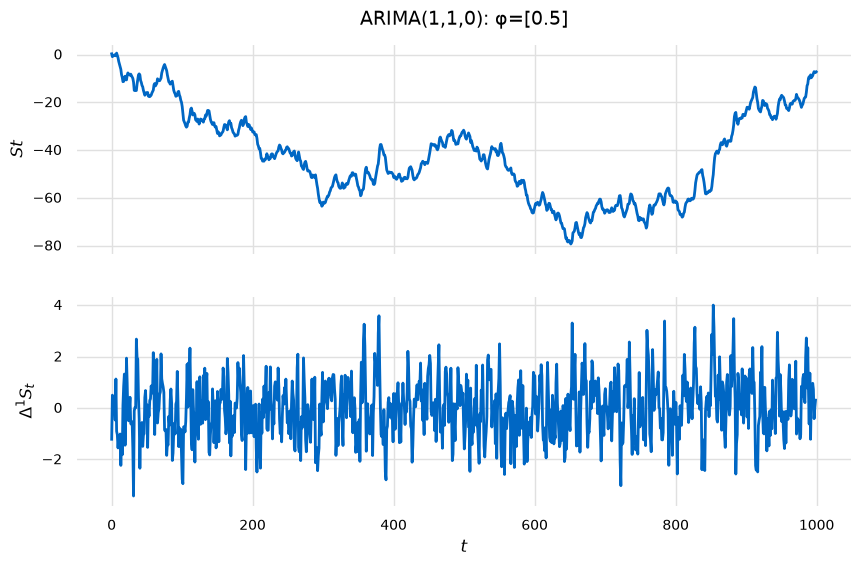

In [7]:
title=f"ARIMA(1,1,0): φ={φ}"
stack([arima_data, diff_1], title=title, xlabel=r"$t$", ylabels=[r"$St$", r"$\Delta^1 S_t$"])

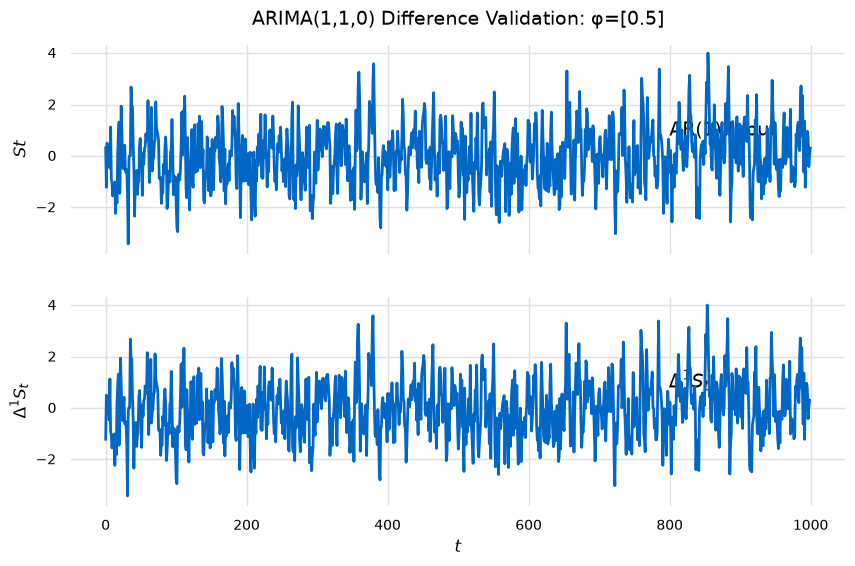

In [8]:
title = f"ARIMA(1,1,0) Difference Validation: φ={φ}"
stack([ar, diff_1], title=title, labels=[r"AR(1) Input", r"$\Delta^1 S_t$"], xlabel=r"$t$", ylabels=[r"$St$", r"$\Delta^1 S_t$"])

In [9]:
result, report = adf.compute_adf_test(arima_data)
result.summary()

╒════════════════╤════════════╕
│ Test Statistic │  -0.677715 │
├────────────────┼────────────┤
│ pvalue         │   0.421996 │
├────────────────┼────────────┤
│ Lags           │   1        │
├────────────────┼────────────┤
│ Number Obs     │ 998        │
╘════════════════╧════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56798 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Passed   │
╘════════════════╧══════════════════╧══════════╛


In [10]:
print(report.to_json(pretty=True))

{
    "status": "FAILED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "STATIONARITY",
    "test_data": [
        {
            "status": "PASSED",
            "stat": {
                "test_id": "a1e8628e-12f5-4441-9fa6-19e6ff935300",
                "label": "$t$",
                "value": -0.6777154611239122
            },
            "pval": {
                "test_id": "a1e8628e-12f5-4441-9fa6-19e6ff935300",
                "label": "$p-value$",
                "value": 0.4219962873005636
            },
            "params": [],
            "sig": {
                "test_id": "a1e8628e-12f5-4441-9fa6-19e6ff935300",
                "label": "1%",
                "value": 0.01
            },
            "lower": {
                "test_id": "a1e8628e-12f5-4441-9fa6-19e6ff935300",
                "label": "$t_L$",
                "value": -2.5679839221127625
            },
            "upper": null,
            "test_id": "a1e8628e-12f5-4441-9fa6-19e6ff935300"
        },
     

In [11]:
result, report = adf.compute_adf_test(diff_1)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -17.9885      │
├────────────────┼───────────────┤
│ pvalue         │   5.21368e-29 │
├────────────────┼───────────────┤
│ Lags           │   0           │
├────────────────┼───────────────┤
│ Number Obs     │ 998           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56798 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


In [12]:
print(report.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "STATIONARITY",
    "test_data": [
        {
            "status": "FAILED",
            "stat": {
                "test_id": "51c61626-97e1-4dbc-ba16-696d1f094dcc",
                "label": "$t$",
                "value": -17.988468929262144
            },
            "pval": {
                "test_id": "51c61626-97e1-4dbc-ba16-696d1f094dcc",
                "label": "$p-value$",
                "value": 5.213679821649773e-29
            },
            "params": [],
            "sig": {
                "test_id": "51c61626-97e1-4dbc-ba16-696d1f094dcc",
                "label": "1%",
                "value": 0.01
            },
            "lower": {
                "test_id": "51c61626-97e1-4dbc-ba16-696d1f094dcc",
                "label": "$t_L$",
                "value": -2.5679839221127625
            },
            "upper": null,
            "test_id": "51c61626-97e1-4dbc-ba16-696d1f094dcc"
        },
  

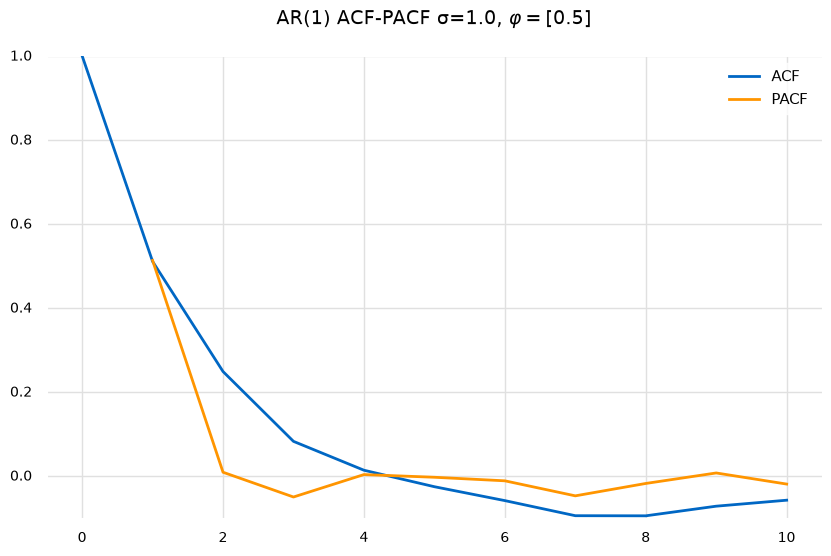

In [13]:
pacf_acf_plot(t, diff_1, nlags, σ, φ)

In [14]:
result, result_model = arima.compute_ar_estimate(diff_1, order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1399.425
Date:                Sun, 30 Aug 2026   AIC                           2804.849
Time:                        11:09:43   BIC                           2819.570
Sample:                             0   HQIC                          2810.444
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0085      0.064     -0.134      0.894      -0.133       0.116
ar.L1          0.5105      0.028     18.184      0.000       0.456       0.566
sigma2         0.9641      0.045     21.437      0.000       0.876       1.052
===================================================================================
Ljung-Box (L1) (Q):                   0.07   Jarque-Bera (JB):                 0.92
Prob(Q):                              0.78   Prob(JB):                         0.63
Heteroskedasticity (H):               1.05   Skew:                             0.03
Prob(H) (two-sided):                  0.69   Kurtosis:                         2.86
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [15]:
print(report.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "STATIONARITY",
    "test_data": [
        {
            "status": "FAILED",
            "stat": {
                "test_id": "51c61626-97e1-4dbc-ba16-696d1f094dcc",
                "label": "$t$",
                "value": -17.988468929262144
            },
            "pval": {
                "test_id": "51c61626-97e1-4dbc-ba16-696d1f094dcc",
                "label": "$p-value$",
                "value": 5.213679821649773e-29
            },
            "params": [],
            "sig": {
                "test_id": "51c61626-97e1-4dbc-ba16-696d1f094dcc",
                "label": "1%",
                "value": 0.01
            },
            "lower": {
                "test_id": "51c61626-97e1-4dbc-ba16-696d1f094dcc",
                "label": "$t_L$",
                "value": -2.5679839221127625
            },
            "upper": null,
            "test_id": "51c61626-97e1-4dbc-ba16-696d1f094dcc"
        },
  

## $\text{ARIMA}(1,2,0)$ Example

In [16]:
φ = [0.75]
d = 2
_, ar = arima.create_ar_source(φ=φ, npts=nsample)
t, arima_data = arima.create_arima_from_arma_source(arma=ar, d=d, npts=nsample)
tdiff_1, diff_1 = stats.compute_ndiff(t, arima_data, ndiff=1)
tdiff_2, diff_2 = stats.compute_ndiff(t, arima_data, ndiff=2)

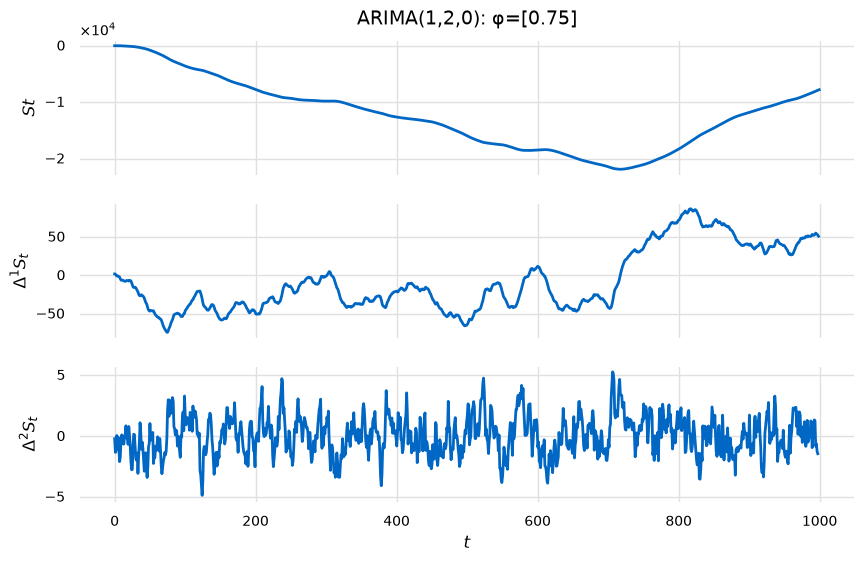

In [17]:
title = f"ARIMA(1,2,0): φ={φ}"
stack([arima_data, diff_1, diff_2], title=title, xlabel=r"$t$", ylabels=[r"$St$", r"$\Delta^1 S_t$", r"$\Delta^2 S_t$"])

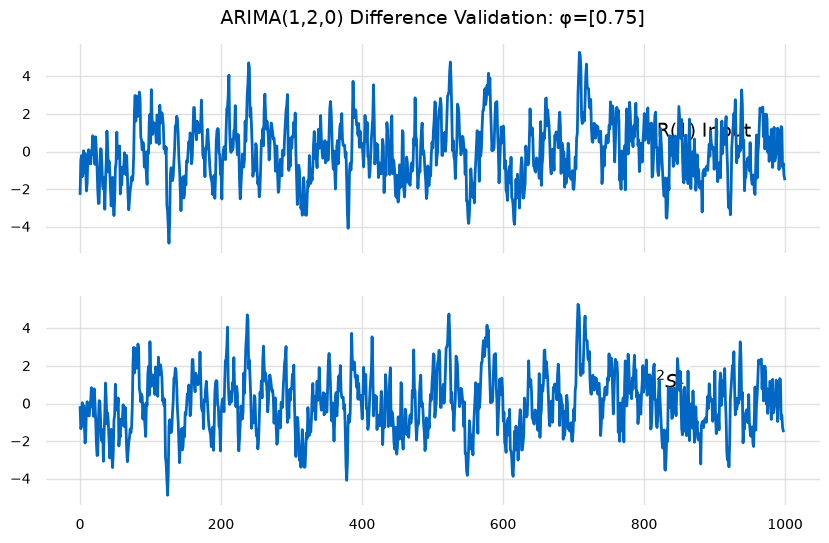

In [18]:
title = f"ARIMA(1,2,0) Difference Validation: φ={φ}"
stack([ar, diff_2], title=title, labels=[r"AR(1) Input", r"$\Delta^2 S_t$"])

In [19]:
result, report = adf.compute_adf_test(arima_data)
result.summary()

╒════════════════╤════════════╕
│ Test Statistic │  -0.937506 │
├────────────────┼────────────┤
│ pvalue         │   0.313425 │
├────────────────┼────────────┤
│ Lags           │   2        │
├────────────────┼────────────┤
│ Number Obs     │ 997        │
╘════════════════╧════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Passed   │
╘════════════════╧══════════════════╧══════════╛


In [20]:
print(report.to_json(pretty=True))

{
    "status": "FAILED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "STATIONARITY",
    "test_data": [
        {
            "status": "PASSED",
            "stat": {
                "test_id": "60a3c3ce-218a-4b13-8ecc-bbba9a8ef7bf",
                "label": "$t$",
                "value": -0.9375062514926732
            },
            "pval": {
                "test_id": "60a3c3ce-218a-4b13-8ecc-bbba9a8ef7bf",
                "label": "$p-value$",
                "value": 0.31342534671473626
            },
            "params": [],
            "sig": {
                "test_id": "60a3c3ce-218a-4b13-8ecc-bbba9a8ef7bf",
                "label": "1%",
                "value": 0.01
            },
            "lower": {
                "test_id": "60a3c3ce-218a-4b13-8ecc-bbba9a8ef7bf",
                "label": "$t_L$",
                "value": -2.5679861764430703
            },
            "upper": null,
            "test_id": "60a3c3ce-218a-4b13-8ecc-bbba9a8ef7bf"
        },
    

In [21]:
result, report = adf.compute_adf_test(diff_1)
result.summary()

╒════════════════╤═══════════╕
│ Test Statistic │  -1.59479 │
├────────────────┼───────────┤
│ pvalue         │   0.10438 │
├────────────────┼───────────┤
│ Lags           │   1       │
├────────────────┼───────────┤
│ Number Obs     │ 997       │
╘════════════════╧═══════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Passed   │
╘════════════════╧══════════════════╧══════════╛


In [22]:
print(report.to_json(pretty=True))

{
    "status": "FAILED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "STATIONARITY",
    "test_data": [
        {
            "status": "PASSED",
            "stat": {
                "test_id": "851f2d1a-355b-4d8e-b0e8-8f37401e4c03",
                "label": "$t$",
                "value": -1.5947904871434464
            },
            "pval": {
                "test_id": "851f2d1a-355b-4d8e-b0e8-8f37401e4c03",
                "label": "$p-value$",
                "value": 0.10437994176985876
            },
            "params": [],
            "sig": {
                "test_id": "851f2d1a-355b-4d8e-b0e8-8f37401e4c03",
                "label": "1%",
                "value": 0.01
            },
            "lower": {
                "test_id": "851f2d1a-355b-4d8e-b0e8-8f37401e4c03",
                "label": "$t_L$",
                "value": -2.5679861764430703
            },
            "upper": null,
            "test_id": "851f2d1a-355b-4d8e-b0e8-8f37401e4c03"
        },
    

In [23]:
result, report = adf.compute_adf_test(diff_2)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -10.9107      │
├────────────────┼───────────────┤
│ pvalue         │   1.10389e-19 │
├────────────────┼───────────────┤
│ Lags           │   0           │
├────────────────┼───────────────┤
│ Number Obs     │ 997           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


In [24]:
print(report.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "STATIONARITY",
    "test_data": [
        {
            "status": "FAILED",
            "stat": {
                "test_id": "db0aa7eb-6e58-4d23-a1fc-247ee32fe11e",
                "label": "$t$",
                "value": -10.91069609579988
            },
            "pval": {
                "test_id": "db0aa7eb-6e58-4d23-a1fc-247ee32fe11e",
                "label": "$p-value$",
                "value": 1.103890833265382e-19
            },
            "params": [],
            "sig": {
                "test_id": "db0aa7eb-6e58-4d23-a1fc-247ee32fe11e",
                "label": "1%",
                "value": 0.01
            },
            "lower": {
                "test_id": "db0aa7eb-6e58-4d23-a1fc-247ee32fe11e",
                "label": "$t_L$",
                "value": -2.5679861764430703
            },
            "upper": null,
            "test_id": "db0aa7eb-6e58-4d23-a1fc-247ee32fe11e"
        },
   

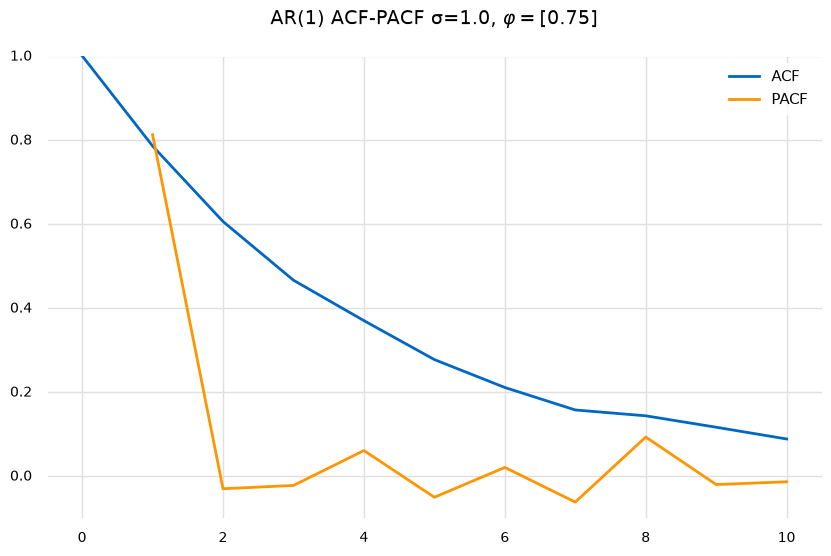

In [25]:
pacf_acf_plot(t, diff_2, nlags, σ, φ)

In [26]:
result, result_model = arima.compute_ar_estimate(diff_2, order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  998
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1399.553
Date:                Sun, 30 Aug 2026   AIC                           2805.106
Time:                        11:09:44   BIC                           2819.823
Sample:                             0   HQIC                          2810.700
                                - 998                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0427      0.146      0.292      0.770      -0.244       0.329
ar.L1          0.7851      0.019     40.265      0.000       0.747       0.823
sigma2         0.9664      0.045     21.653      0.000       0.879       1.054
===================================================================================
Ljung-Box (L1) (Q):                   0.55   Jarque-Bera (JB):                 2.41
Prob(Q):                              0.46   Prob(JB):                         0.30
Heteroskedasticity (H):               1.18   Skew:                            -0.11
Prob(H) (two-sided):                  0.12   Kurtosis:                         2.91
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## $\text{ARIMA}(2,2,0)$ Example

In [27]:
φ = [0.25, 0.4]
d = 2
_, ar = arima.create_ar_source(φ=φ, npts=nsample)
t, arima_data = arima.create_arima_from_arma_source(arma=ar, d=d, npts=nsample)
tdiff_1, diff_1 = stats.compute_ndiff(t, arima_data, ndiff=1)
tdiff_2, diff_2 = stats.compute_ndiff(t, arima_data, ndiff=2)

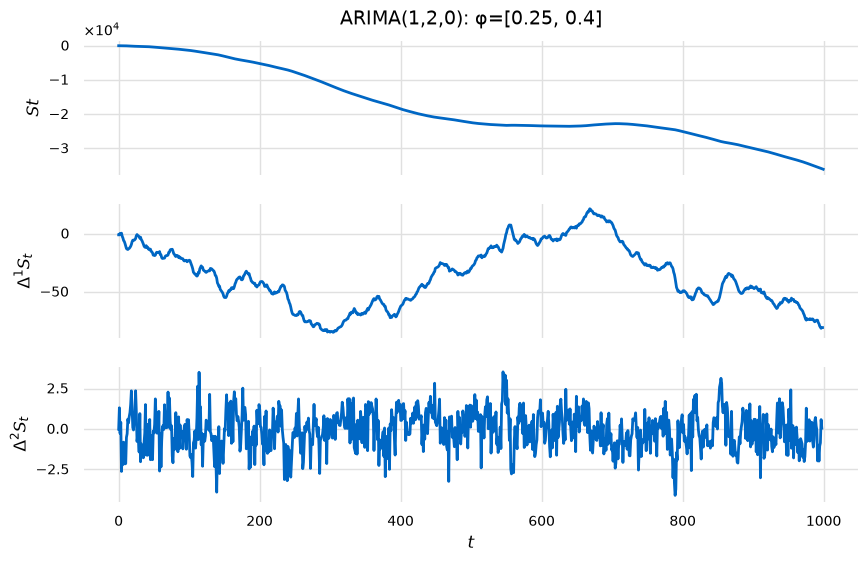

In [28]:
title = f"ARIMA(1,2,0): φ={φ}"
stack([arima_data, diff_1, diff_2], title=title, xlabel=r"$t$", ylabels=[r"$St$", r"$\Delta^1 S_t$", r"$\Delta^2 S_t$"])

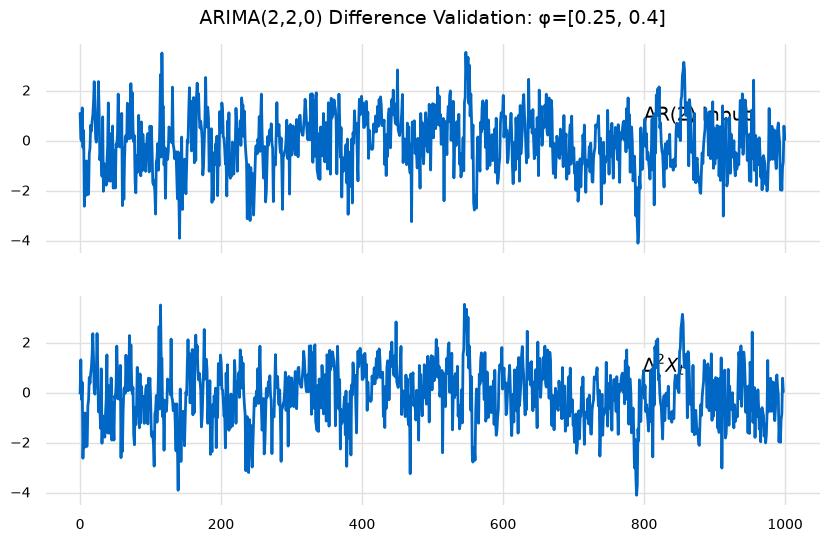

In [29]:
title = f"ARIMA(2,2,0) Difference Validation: φ={φ}"
stack([ar, diff_2], title=title, labels=[r"AR(2) Input", r"$\Delta^2 X_t$"])

In [30]:
result, report = adf.compute_adf_test(arima_data)
result.summary()

╒════════════════╤════════════╕
│ Test Statistic │   0.831779 │
├────────────────┼────────────┤
│ pvalue         │   0.890369 │
├────────────────┼────────────┤
│ Lags           │   3        │
├────────────────┼────────────┤
│ Number Obs     │ 996        │
╘════════════════╧════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Passed   │
╘════════════════╧══════════════════╧══════════╛


In [31]:
print(report.to_json(pretty=True))

{
    "status": "FAILED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "STATIONARITY",
    "test_data": [
        {
            "status": "PASSED",
            "stat": {
                "test_id": "feeedda0-dfc9-4bff-b77a-e3a292eb386f",
                "label": "$t$",
                "value": 0.8317785954370788
            },
            "pval": {
                "test_id": "feeedda0-dfc9-4bff-b77a-e3a292eb386f",
                "label": "$p-value$",
                "value": 0.8903689545567559
            },
            "params": [],
            "sig": {
                "test_id": "feeedda0-dfc9-4bff-b77a-e3a292eb386f",
                "label": "1%",
                "value": 0.01
            },
            "lower": {
                "test_id": "feeedda0-dfc9-4bff-b77a-e3a292eb386f",
                "label": "$t_L$",
                "value": -2.567988435307495
            },
            "upper": null,
            "test_id": "feeedda0-dfc9-4bff-b77a-e3a292eb386f"
        },
       

In [32]:
result, report = adf.compute_adf_test(diff_1)
result.summary()

╒════════════════╤════════════╕
│ Test Statistic │  -0.104865 │
├────────────────┼────────────┤
│ pvalue         │   0.648318 │
├────────────────┼────────────┤
│ Lags           │   2        │
├────────────────┼────────────┤
│ Number Obs     │ 996        │
╘════════════════╧════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Passed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Passed   │
╘════════════════╧══════════════════╧══════════╛


In [33]:
print(report.to_json(pretty=True))

{
    "status": "FAILED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "STATIONARITY",
    "test_data": [
        {
            "status": "PASSED",
            "stat": {
                "test_id": "36f2267e-c7d9-4250-a5e5-c6033f43af3e",
                "label": "$t$",
                "value": -0.10486472732708643
            },
            "pval": {
                "test_id": "36f2267e-c7d9-4250-a5e5-c6033f43af3e",
                "label": "$p-value$",
                "value": 0.6483182054850998
            },
            "params": [],
            "sig": {
                "test_id": "36f2267e-c7d9-4250-a5e5-c6033f43af3e",
                "label": "1%",
                "value": 0.01
            },
            "lower": {
                "test_id": "36f2267e-c7d9-4250-a5e5-c6033f43af3e",
                "label": "$t_L$",
                "value": -2.567988435307495
            },
            "upper": null,
            "test_id": "36f2267e-c7d9-4250-a5e5-c6033f43af3e"
        },
     

In [34]:
result, report = adf.compute_adf_test(diff_2)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -11.5097      │
├────────────────┼───────────────┤
│ pvalue         │   6.54627e-21 │
├────────────────┼───────────────┤
│ Lags           │   1           │
├────────────────┼───────────────┤
│ Number Obs     │ 996           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56799 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


In [35]:
print(report.to_json(pretty=True))

{
    "status": "PASSED",
    "hyp_type": "LOWER_TAIL",
    "hyp_test_type": "STATIONARITY",
    "test_data": [
        {
            "status": "FAILED",
            "stat": {
                "test_id": "369c098a-738b-43b0-a1fa-724c032f25f9",
                "label": "$t$",
                "value": -11.50970523644974
            },
            "pval": {
                "test_id": "369c098a-738b-43b0-a1fa-724c032f25f9",
                "label": "$p-value$",
                "value": 6.546270688414775e-21
            },
            "params": [],
            "sig": {
                "test_id": "369c098a-738b-43b0-a1fa-724c032f25f9",
                "label": "1%",
                "value": 0.01
            },
            "lower": {
                "test_id": "369c098a-738b-43b0-a1fa-724c032f25f9",
                "label": "$t_L$",
                "value": -2.567988435307495
            },
            "upper": null,
            "test_id": "369c098a-738b-43b0-a1fa-724c032f25f9"
        },
    

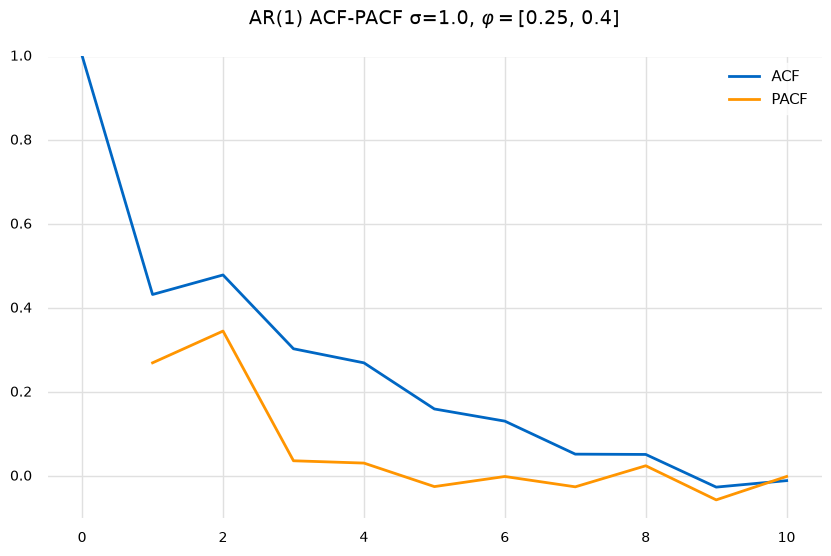

In [36]:
pacf_acf_plot(t, diff_2, nlags, σ, φ)

In [37]:
result, result_model = arima.compute_ar_estimate(diff_2, order=2)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  998
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -1388.264
Date:                Sun, 30 Aug 2026   AIC                           2784.527
Time:                        11:09:45   BIC                           2804.150
Sample:                             0   HQIC                          2791.986
                                - 998                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0775      0.086     -0.904      0.366      -0.246       0.091
ar.L1          0.2763      0.028      9.952      0.000       0.222       0.331
ar.L2          0.3587      0.030     12.049      0.000       0.300       0.417
sigma2         0.9453      0.043     21.808      0.000       0.860       1.030
===================================================================================
Ljung-Box (L1) (Q):                   0.05   Jarque-Bera (JB):                10.44
Prob(Q):                              0.82   Prob(JB):                         0.01
Heteroskedasticity (H):               0.83   Skew:                            -0.25
Prob(H) (two-sided):                  0.08   Kurtosis:                         3.00
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""